In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset
df = pd.read_csv('dataset_limpio.csv', sep=';')


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8789 entries, 0 to 8788
Data columns (total 1 columns):
 #   Column                                                                                 Non-Null Count  Dtype 
---  ------                                                                                 --------------  ----- 
 0   show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in  8789 non-null   object
dtypes: object(1)
memory usage: 68.8+ KB
None


In [3]:
# Conteo exacto de nulos por columna
print(df.isnull().sum())

# Ver filas duplicadas (totales)
print(f"Duplicados totales: {df.duplicated().sum()}")

show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in    0
dtype: int64
Duplicados totales: 0


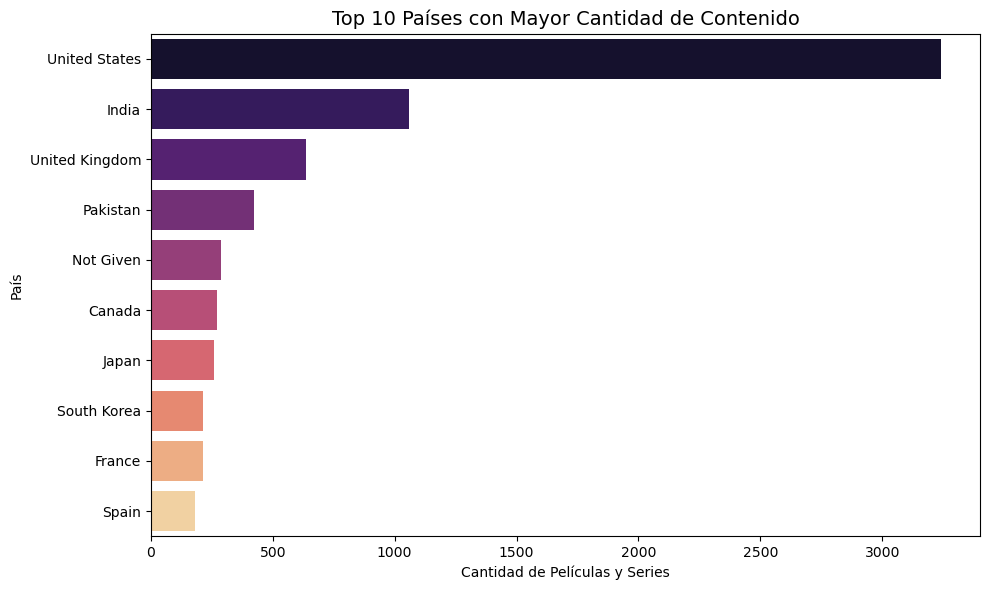

In [ ]:
#Este gráfico cuenta cuántas películas y series 
#tiene cada país y muestra los 10 primeros.

plt.figure(figsize=(10, 6))

# Obtenemos los 10 países más frecuentes contando sus apariciones
top_10_paises = df['country'].value_counts().head(10)

# Al ser nombres largos, una gráfica horizontal (orient='h') se lee mucho mejor
sns.barplot(x=top_10_paises.values, y=top_10_paises.index, palette='magma')

plt.title('Top 10 Países con Mayor Cantidad de Contenido', fontsize=14)
plt.xlabel('Cantidad de Películas y Series')
plt.ylabel('País')
plt.tight_layout()
plt.show()

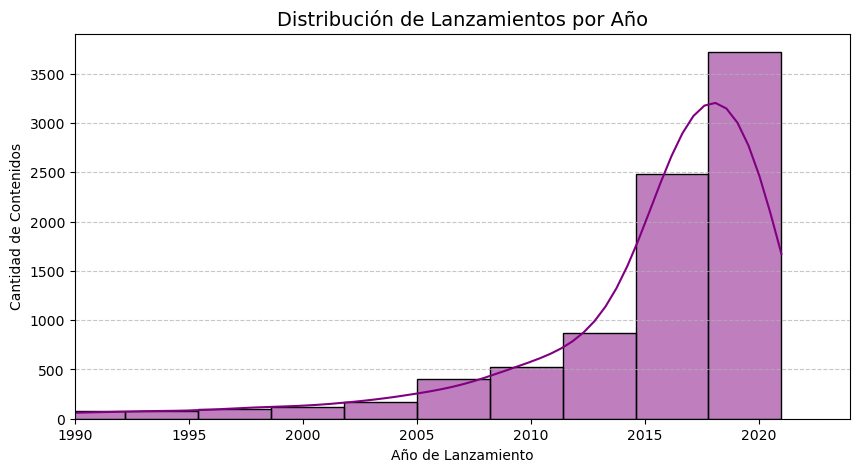

In [ ]:
#¿En qué años se produjeron la mayoría de las
#películas y series que están en la plataforma?
plt.figure(figsize=(10, 5))

# Usamos un histograma acotado desde 1990 para verlo mejor
sns.histplot(data=df, x='release_year', bins=30, kde=True, color='purple')

plt.title('Distribución de Lanzamientos por Año', fontsize=14)
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Cantidad de Contenidos')
plt.xlim(1990, 2024) # Nos enfocamos de 1990 en adelante
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


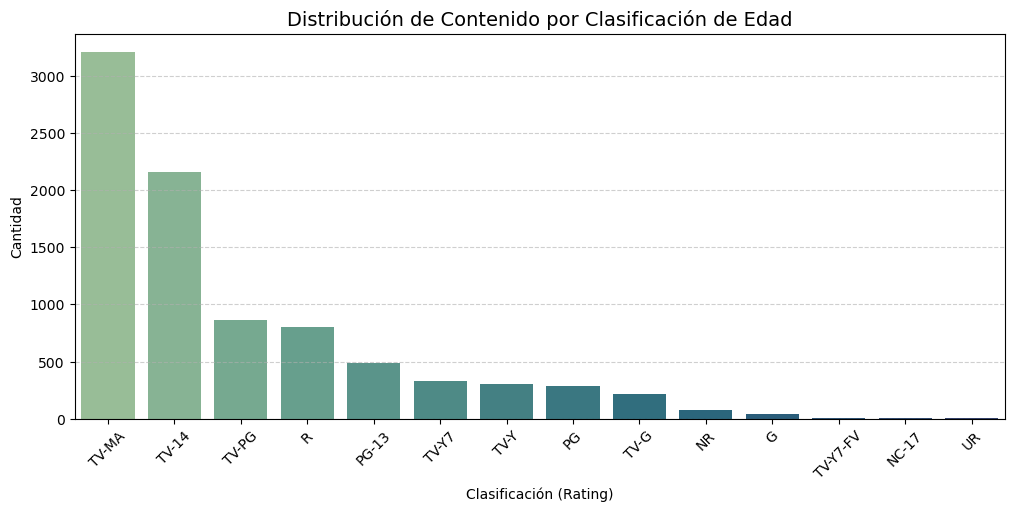

In [ ]:
#Vamos a ver cuáles son las clasificaciones
#(Ratings como TV-MA, PG-13, TV-14, etc.)

plt.figure(figsize=(12, 5))

# El order nos ayudará a organizarlo de mayor a menor número
orden_rating = df['rating'].value_counts().index

plt.grid(True, linestyle='--', alpha=0.6)

sns.countplot(data=df, x='rating', order=orden_rating, palette='crest')

plt.title('Distribución de Contenido por Clasificación de Edad', fontsize=14)
plt.xlabel('Clasificación (Rating)')
plt.ylabel('Cantidad')
plt.xticks(rotation=45) # Giramos un poco los textos para que no se encima
plt.show()


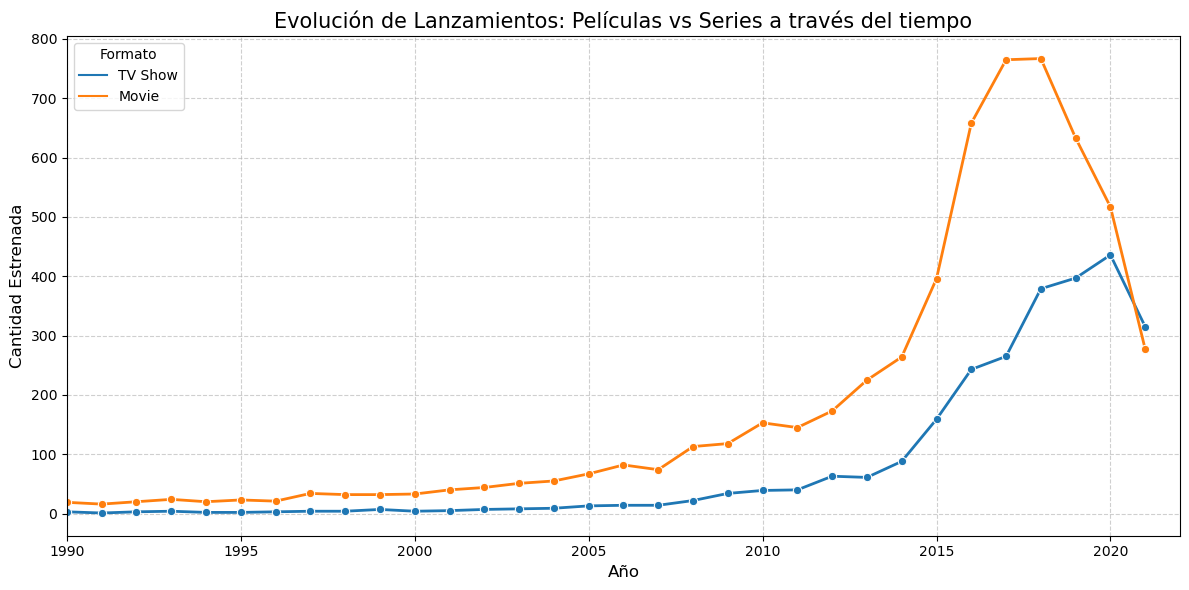

In [ ]:
#Con este gráfico podemos ver si recientemente 
#Netflix ha subido más Series que Películas.
plt.figure(figsize=(12, 6))

# Contamos el número de películas y series por año
tendencia = df.groupby(['release_year', 'type']).size().reset_index(name='count')

sns.lineplot(data=tendencia, x='release_year', y='count', hue='type', marker="o", linewidth=2)

plt.title('Evolución de Lanzamientos: Películas vs Series a través del tiempo', fontsize=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad Estrenada', fontsize=12)
plt.xlim(1990, 2022) 

# --- AÑADIDOS PARA MEJOR VERIFICACIÓN ---

# Activamos la cuadrícula (grid) para que aparezcan las líneas guía
# linestyle='--' las hace punteadas para que no saturen la vista
# alpha=0.6 controla la transparencia de las líneas
plt.grid(True, linestyle='--', alpha=0.6)

# (Opcional) Mostrar marcas en el eje X cada 2 años para mayor precisión
# import numpy as np
# plt.xticks(np.arange(1990, 2023, 2))

# -----------------------------------------

plt.legend(title='Formato')
plt.tight_layout()
plt.show()


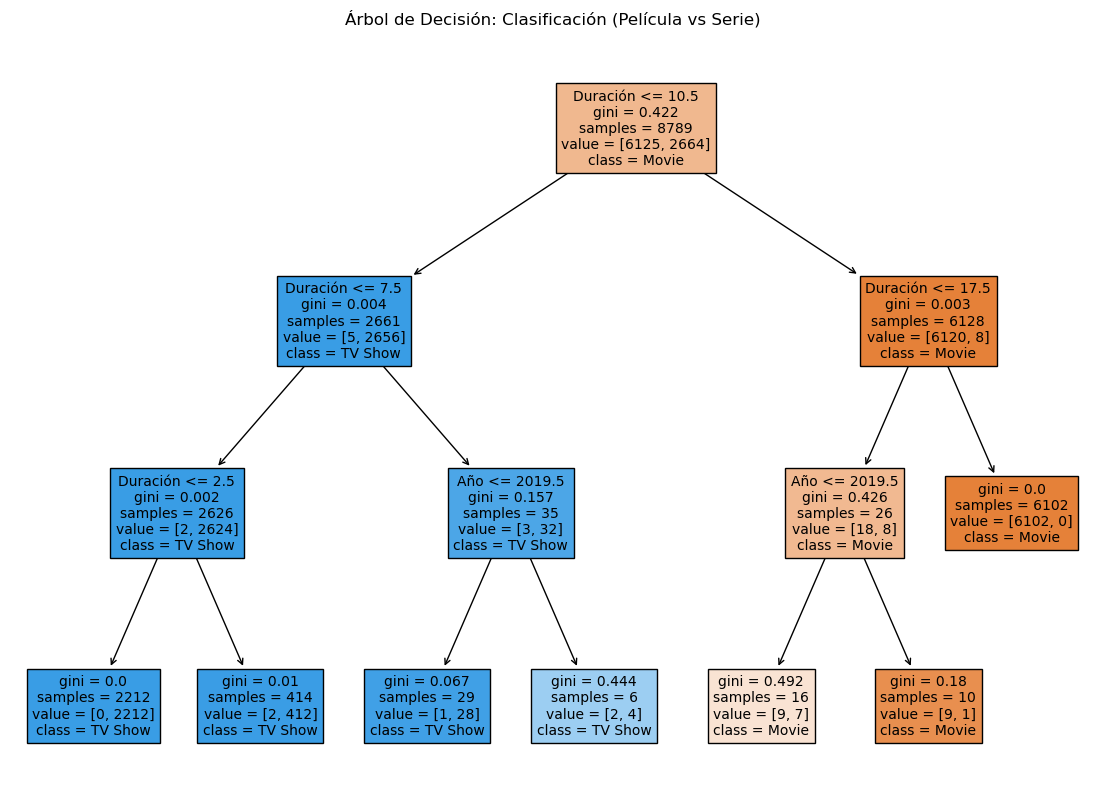

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Carga de datos
df = pd.read_csv('netflix1.csv', sep=';')

# 2. Preprocesamiento
# Convertimos el objetivo 'type' a números: Movie = 0, TV Show = 1
df['type_num'] = df['type'].map({'Movie': 0, 'TV Show': 1})

# --- SOLUCIÓN AL ERROR ---
# El error ocurre porque la columna 'duration' tiene texto ("min", "Season").
# Vamos a extraer solo el número usando una expresión regular.
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

# Eliminamos filas que tengan valores nulos después de la conversión para evitar errores
df = df.dropna(subset=['release_year', 'duration_num', 'type_num'])

# 3. Definir variables
# Ahora usamos 'duration_num' en lugar de la columna con texto
X = df[['release_year']] 
y = df['type_num']

# 4. Crear el modelo usando índice de Gini y una profundidad baja
modelo = DecisionTreeClassifier(criterion='gini', max_depth=3)
modelo.fit(X, y)

# 5. Visualización del Árbol
plt.figure(figsize=(14, 10))
plot_tree(modelo, 
          filled=True, 
          feature_names=['Año'], 
          class_names=['Movie', 'TV Show'],
          fontsize=10)
plt.title("Árbol de Decisión: Clasificación (Película vs Serie)")
plt.show()


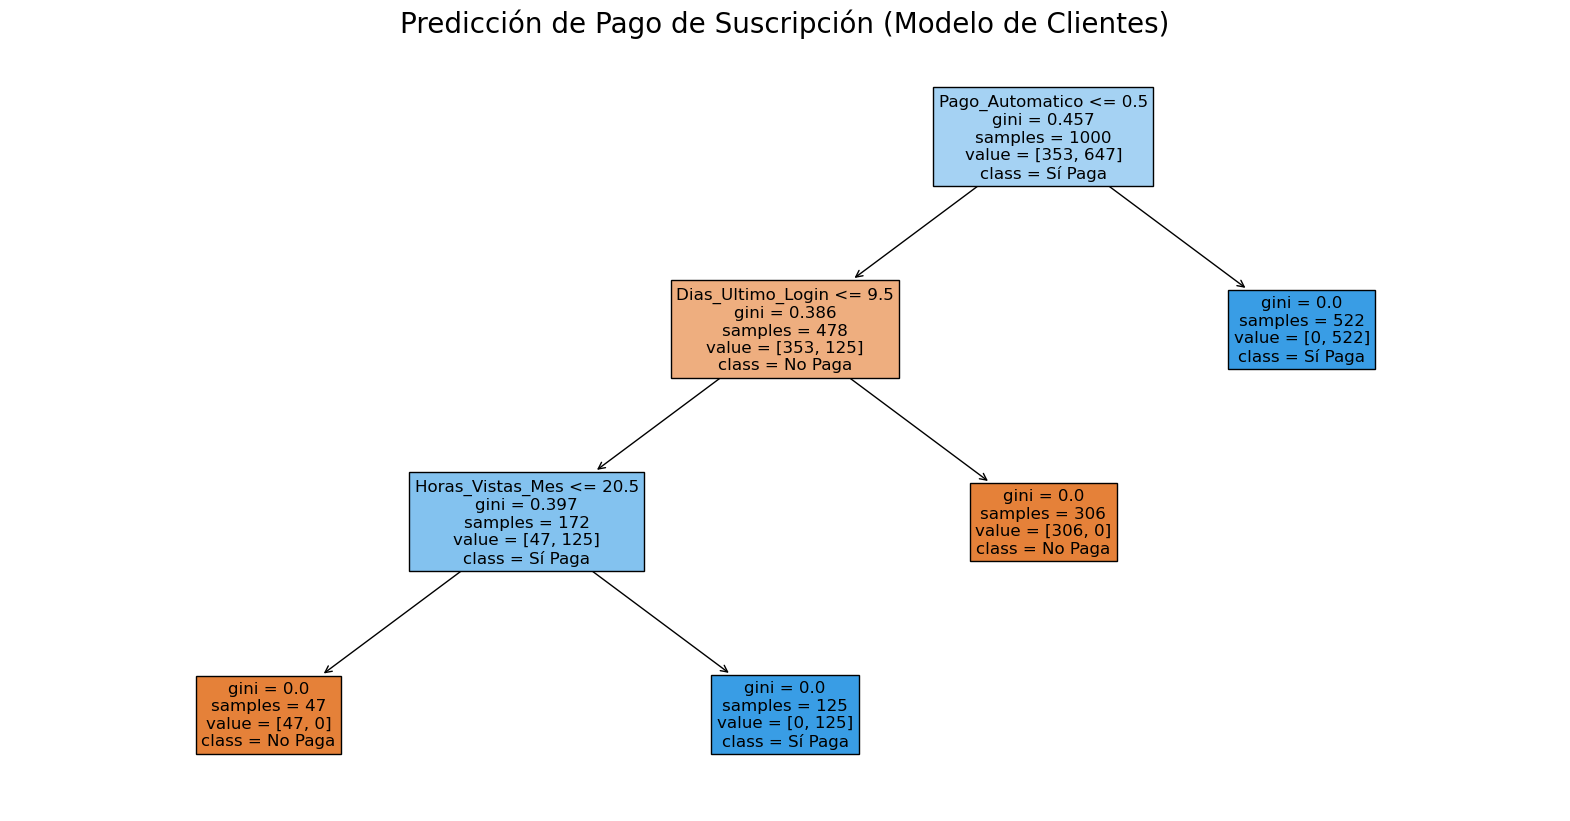

In [11]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Creamos datos sintéticos (Simulando 1,000 clientes)
np.random.seed(42)
n_clientes = 1000

data = {
    'Horas_Vistas_Mes': np.random.randint(0, 100, n_clientes),
    'Dias_Ultimo_Login': np.random.randint(0, 30, n_clientes),
    'Pago_Automatico': np.random.choice([0, 1], n_clientes), # 0 = No, 1 = Sí
    'Antiguedad_Meses': np.random.randint(1, 60, n_clientes)
}

df_clientes = pd.DataFrame(data)

# Creamos una regla lógica para definir quién paga (el objetivo)
# Pagará si ve más de 20 horas O si tiene pago automático O si entró hace menos de 5 días
df_clientes['Pagara'] = ((df_clientes['Horas_Vistas_Mes'] > 20) & 
                         (df_clientes['Dias_Ultimo_Login'] < 10) | 
                         (df_clientes['Pago_Automatico'] == 1)).astype(int)

# 2. Definir variables
X = df_clientes[['Horas_Vistas_Mes', 'Dias_Ultimo_Login', 'Pago_Automatico', 'Antiguedad_Meses']]
y = df_clientes['Pagara']

# 3. Crear y entrenar el modelo
# Usamos max_depth=3 para que el árbol no sea gigante y se pueda leer
modelo_churn = DecisionTreeClassifier(max_depth=3, criterion='gini')
modelo_churn.fit(X, y)

# 4. Visualizar el árbol de decisión
plt.figure(figsize=(20,10))
plot_tree(modelo_churn, 
          filled=True, 
          feature_names=X.columns, 
          class_names=['No Paga', 'Sí Paga'],
          fontsize=12)

plt.title("Predicción de Pago de Suscripción (Modelo de Clientes)", fontsize=20)
plt.show()


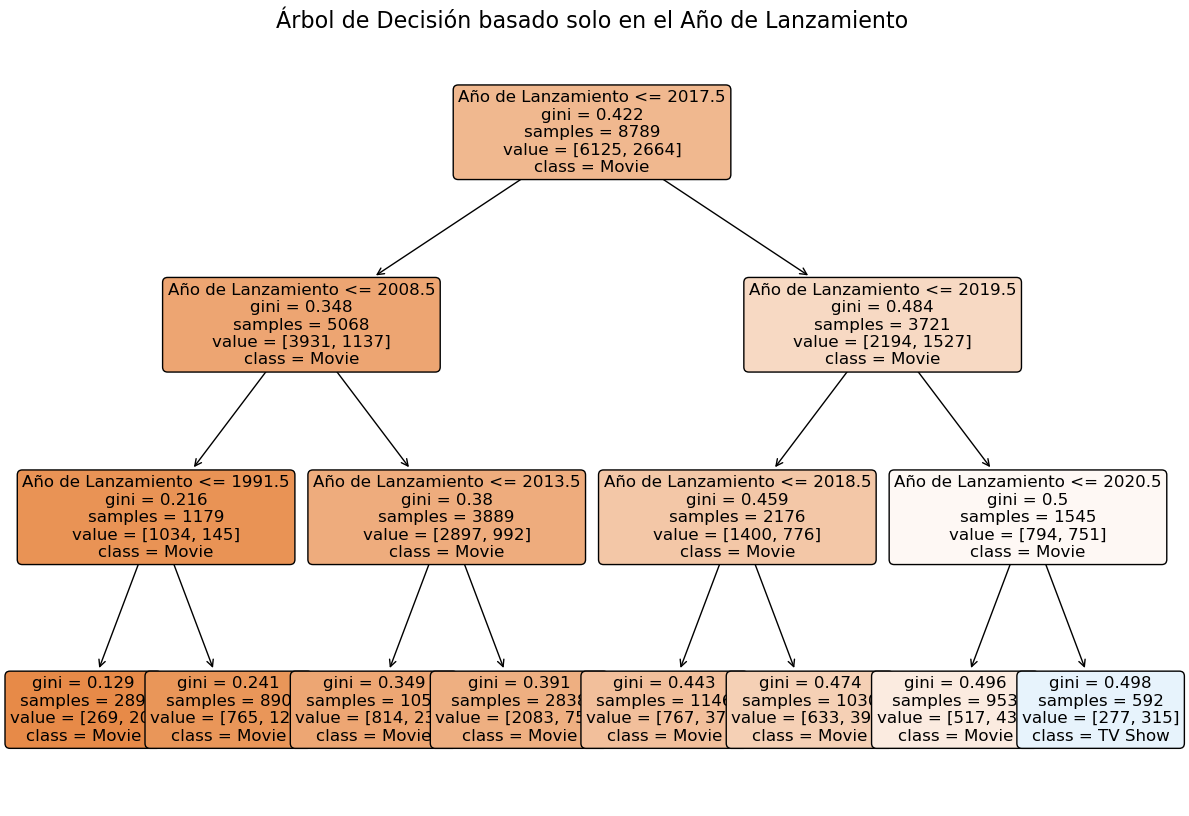

In [12]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Carga y preparación de datos
df = pd.read_csv('netflix1.csv', sep=';')
df['type_num'] = df['type'].map({'Movie': 0, 'TV Show': 1})

# Eliminamos filas sin año por si acaso
df = df.dropna(subset=['release_year', 'type_num'])

# 2. Definir variables (Solo el Año)
X = df[['release_year']] 
y = df['type_num']

# 3. Crear el modelo
# Ajustamos max_depth=3 para que los nodos coincidan con los que viste antes
modelo_anio = DecisionTreeClassifier(max_depth=3, criterion='gini')
modelo_anio.fit(X, y)

# 4. Visualización
plt.figure(figsize=(15, 10))
plot_tree(modelo_anio, 
          filled=True, 
          feature_names=['Año de Lanzamiento'], 
          class_names=['Movie', 'TV Show'],
          rounded=True,
          fontsize=12)

plt.title("Árbol de Decisión basado solo en el Año de Lanzamiento", fontsize=16)
plt.show()
